In [92]:
import numpy as np
import tensorflow.keras as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

from tqdm import tqdm

In [93]:
class InitStrategy:

  def __init__(self, init_func, name=""):

    self.init_func = init_func
    self.name = name

  def apply(self, num_units, input_dim):

    return self.init_func(num_units, input_dim)

class DecayLearningOptimizer:

  def __init__(self, start_lr=1, decay=0.95, name="Decay"):

    self.start_lr = start_lr
    self.decay = decay
    self.name = name
    self.lr = start_lr

  def get_lr(self):

    self.lr *= self.decay

    return self.lr



class ActivationFunction:

  def __init__(self, func, deriv_func=None, name=""):

    self.func = func
    self.deriv_func = deriv_func
    self.name = name

  def apply(self, X):

    return self.func(X)

  def apply_deriv(self, X):

    return self.deriv_func(X)

class EvaluationFunction:

  def __init__(self, func, deriv_func=None, name=""):

    self.func = func
    self.deriv_func = deriv_func
    self.name = name

  def apply(self, y_true, y_hat):

    return self.func(y_true, y_hat)

  def apply_deriv(self, y_true, y_hat):

    return self.deriv_func(y_true, y_hat)

class Layer:

  def __init__(self, is_output=False, is_trainable=True, name="Generic_Layer", skip_after_train=False):

    self.is_output = is_output
    self.is_trainable = is_trainable
    self.name = name
    self.skip_after_train = skip_after_train

  def feed(self, inputs):

    pass

  def get_info(self):

    return f"Name: {self.name}\n  Output Layer?: {self.is_output}\n  Trainable?: {self.is_trainable}\n  Skip after training?: {self.skip_after_train}\n"

class DenseLayer(Layer):

  def __init__(self, num_units, activation_func=None, is_output=False, is_trainable=True, init_strat=None):
    super().__init__(is_output, is_trainable, "Dense_Layer", False)

    self.num_units = num_units
    self.activation_func = activation_func
    self.init_strat = init_strat

    self.W = None
    self.b = None

  def feed(self, inputs):

    linear_output = (self.W @ inputs) + self.b

    activated_output = linear_output

    if self.activation_func:

      activated_output = self.activation_func.apply(linear_output)

    return [linear_output, activated_output]

  def init_params(self, input_dim):

    self.W, self.b = self.init_strat.apply(self.num_units, input_dim)


  def get_info(self):

    return f"Name: {self.name}\n  Num Units: {self.num_units}\n  Activation: {self.activation_func.name if self.activation_func else None}\n  Parameter Init: {self.init_strat.name if self.init_strat else None}\n  Output Layer?: {self.is_output}\n  Trainable?: {self.is_trainable}\n  Skip after training?: {self.skip_after_train}\n"

class DropoutLayer(Layer):

  def __init__(self, drop_rate=0.3):

    super().__init__(True, False, "Dropout_Layer", True)
    self.drop_rate = drop_rate

  def feed(self, inputs):

    choices = np.arange(0, inputs.shape[0]).astype(int)
    for _ in range(int(self.drop_rate*inputs.shape[0])):

      random_ind = np.random.choice(choices, replace=False)
      inputs[random_ind, :] = np.zeros(inputs.shape[1])

    return inputs, inputs

  def get_info(self):

    return f"Name: {self.name}\n  Dropout Rate: {self.drop_rate}\n  Output Layer?: {self.is_output}\n  Trainable?: {self.is_trainable}\n  Skip after training?: {self.skip_after_train}\n"


class NeuralNetwork:

  def __init__(self, layers, input_dim=None, opt=None, eval_func=None):

    self.layers = layers
    self.trainable_layers = [lyr for lyr in layers if lyr.is_trainable]
    self.eval_func = eval_func
    self.input_dim = input_dim
    self.opt = opt

    prev_dim = input_dim[0]

    for layer in self.trainable_layers:

      layer.init_params(prev_dim)

      prev_dim = layer.num_units


  def get_architecture(self):

    print("====Neural Network Architecture=================")
    print("Evaluation Function: ",self.eval_func.name)
    print("Learning Optimizer: ",self.opt.name)
    print("Input Dimesion: ",self.input_dim)
    print("Number of Layers: ",len(self.layers))

    for i, layer in enumerate(self.layers):

      print(f"Layer {i+1}:\n")
      print(layer.get_info())

    print("================================================")


  def feed_forward(self, X, is_training=True):

    output = X
    inputs = []
    outputs = []

    if is_training:

      for layer in self.layers:

          inputs.append(output)

          linear_output, activated_output = layer.feed(output)

          outputs.append([linear_output, activated_output])

          output = activated_output

      return output, inputs, outputs

    else:

      for layer in self.layers:

        if layer.skip_after_train:

          continue

        inputs.append(output)

        linear_output, activated_output = layer.feed(output)

        outputs.append([linear_output, activated_output])

        output = activated_output

      return output, inputs, outputs


  def back_propagation(self, inputs, outputs, y_true, y_hat):

    gradients = []

    num_layers = len(self.layers)

    curr_grad = self.eval_func.apply_deriv(y_true, y_hat)

    for i in reversed(range(num_layers)):

      if self.layers[i].is_trainable:

        if self.layers[i].activation_func and not self.layers[i].is_output:

          curr_grad = curr_grad * self.layers[i].activation_func.apply_deriv(outputs[i][0])

        curr_grad_W = curr_grad @ inputs[i].T / inputs[i].shape[1]
        curr_grad_b = np.sum(curr_grad, axis=1, keepdims=True) / inputs[i].shape[1]

        curr_grad = self.layers[i].W.T @ curr_grad

        gradients.append([curr_grad_W.copy(), curr_grad_b.copy()])

      else:

        gradients.append(None)

    return gradients[::-1]

  def update_weights(self, gradients, lr):

    for i in range(len(self.layers)):

      if self.layers[i].is_trainable:

        W, b = gradients[i][0], gradients[i][1]

        self.layers[i].W -= lr*W
        self.layers[i].b -= lr*b

  def evaluate(self, y_true, y_hat):

    return self.eval_func.apply(y_true, y_hat)


In [94]:
# inputs = np.random.randn(10, 100)
# lbls = inputs[0] * (3/9) + inputs[1] **2
# lbls = np.reshape(lbls, (1, -1))
# inputs.shape, lbls.shape

(x_train, y_train), (x_test, y_test) = mnist.load_data()

y_train = np.array([[0 if ind != elem else 1 for ind in range(10)] for elem in y_train])
y_test = np.array([[0 if ind != elem else 1 for ind in range(10)] for elem in y_test])


x_train = np.reshape(x_train, (x_train.shape[0], -1)).T
x_test = np.reshape(x_test, (x_test.shape[0], -1)).T

x_train = (x_train - 0) / (255 - 0)
x_test = (x_test - 0) / (255 - 0)

y_train = y_train.T
y_test = y_test.T

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((784, 60000), (784, 10000), (10, 60000), (10, 10000))

In [95]:
y_train[:, [0,1,2,3,4,5,6,7,8,9]]

array([[0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]])

In [96]:
def he_init(num_units, input_dim):

  W = np.random.randn(num_units, input_dim) * np.sqrt(2/input_dim)
  b = np.zeros((num_units, 1))

  return W, b

def random_init(num_units, input_dim):

  W = np.random.randn(num_units, input_dim) * 0.01
  b = np.zeros((num_units, 1))

  return W, b


In [97]:
def RELU(X):

  return np.maximum(0, X).astype(float)

def deriv_RELU(X):

  return (X > 0).astype(float)

def root_mean_squared_error(y_true, y_hat):

  return (1/y_true.shape[1])*np.sqrt(np.sum((y_true - y_hat)**2))

def mean_squared_error(y_true, y_hat):

  return (1/y_true.shape[1])*np.sum((y_true - y_hat)**2)

def deriv_mean_squared_error(y_true, y_hat):

  return (-2/y_true.shape[1]) * (y_true - y_hat)

def sigmoid(X):

  return 1/(1 + np.exp(-X))

def deriv_sigmoid(X):

  return sigmoid(X) * (1 - sigmoid(X))

def softmax(X):

  # return np.apply_along_axis(lambda col: (np.e**col) / np.sum(np.e**col), axis=1, arr=X) OVERFLOW RIP
  exp_X = np.exp(X - np.max(X, axis=0, keepdims=True))
  return exp_X / np.sum(exp_X, axis=0, keepdims=True)

def cross_entropy_loss(y_true, y_hat):

  y_hat = np.clip(y_hat, 1e-15, 1 - 1e-15)
  return -np.mean(np.sum((y_true * np.log(y_hat)), axis=0))

def deriv_cross_entropy_loss_with_softmax(y_true, y_hat):

  return (y_hat - y_true)

def accuracy(y_true, y_hat):

  return np.mean(np.argmax(y_true, axis=0) == np.argmax(y_hat, axis=0))

def decay(prev_lr, rate=0.9):

  return prev_lr - prev_lr*rate


====Neural Network Architecture=================
Evaluation Function:  Cross Entropy Loss
Learning Optimizer:  Decay
Input Dimesion:  (784, 60000)
Number of Layers:  4
Layer 1:

Name: Dense_Layer
  Num Units: 128
  Activation: RELU
  Parameter Init: HE Init
  Output Layer?: False
  Trainable?: True
  Skip after training?: False

Layer 2:

Name: Dense_Layer
  Num Units: 64
  Activation: RELU
  Parameter Init: HE Init
  Output Layer?: False
  Trainable?: True
  Skip after training?: False

Layer 3:

Name: Dropout_Layer
  Dropout Rate: 0.3
  Output Layer?: True
  Trainable?: False
  Skip after training?: True

Layer 4:

Name: Dense_Layer
  Num Units: 10
  Activation: Softmax
  Parameter Init: HE Init
  Output Layer?: True
  Trainable?: True
  Skip after training?: False



100%|██████████| 10/10 [00:22<00:00,  2.28s/it]


Text(0.5, 1.0, 'Accuracy')

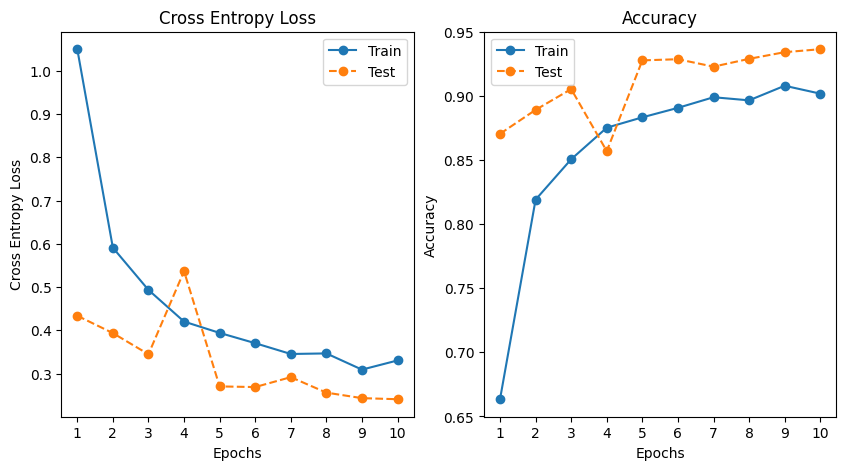

In [98]:
relu_actv = ActivationFunction(RELU, deriv_RELU, "RELU")
sig_actv = ActivationFunction(sigmoid, deriv_sigmoid, "Sigmoid")
soft_actv = ActivationFunction(softmax, None, "Softmax")

mse_eval = EvaluationFunction(mean_squared_error, deriv_mean_squared_error, "Mean Squared Error")
cross_eval = EvaluationFunction(cross_entropy_loss, deriv_cross_entropy_loss_with_softmax, "Cross Entropy Loss")
acc_eval = EvaluationFunction(accuracy, None, 'Accuracy')

decay_opt = DecayLearningOptimizer(start_lr=0.1, decay=0.95)

he_init = InitStrategy(he_init, name="HE Init")


sequence = [
    DenseLayer(128, activation_func=relu_actv, init_strat=he_init),
    DenseLayer(64, activation_func=relu_actv, init_strat=he_init),
    DropoutLayer(0.3),
    DenseLayer(10, activation_func=soft_actv, is_output=True, init_strat=he_init),
]

nn = NeuralNetwork(sequence, eval_func=cross_eval, input_dim=x_train.shape, opt=decay_opt)
nn.get_architecture()


n_epochs = 10
batch_size = 512
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epochs in tqdm(range(n_epochs)):

  temp_train_acc, temp_train_loss = [], []

  lr = nn.opt.get_lr()

  perm = np.random.permutation(x_train.shape[1])
  x_train_perm = x_train[:, perm]
  y_train_perm = y_train[:, perm]

  for i in range(0, x_train.shape[1], batch_size):

    x_train_batch = x_train_perm[:, i:i+batch_size]
    y_train_batch = y_train_perm[:, i:i+batch_size]

    out, ins, outs = nn.feed_forward(x_train_batch, is_training=True)
    train_loss = nn.eval_func.apply(y_train_batch, out)
    train_acc = acc_eval.apply(y_train_batch, out)

    gradients = nn.back_propagation(ins, outs, y_train_batch, out)
    nn.update_weights(gradients, lr)

    temp_train_loss.append(np.mean(train_loss))
    temp_train_acc.append(train_acc)


  test_out, _, _ = nn.feed_forward(x_test, is_training=False)
  test_loss = nn.eval_func.apply(y_test, test_out)
  test_acc = acc_eval.apply(y_test, test_out)


  train_losses.append(np.mean(temp_train_loss))
  test_losses.append(test_loss)

  train_accs.append(np.mean(temp_train_acc))
  test_accs.append(test_acc)

epochs = [i for i in range(1, n_epochs+1)]

fig = plt.figure(figsize=(10, 5))

fig.add_subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train", marker="o")
plt.plot(epochs, test_losses, label="Test", marker="o", linestyle='--')
plt.xticks(epochs)
plt.legend()
plt.xlabel("Epochs")
plt.ylabel(nn.eval_func.name)
plt.title(nn.eval_func.name)

fig.add_subplot(1, 2, 2)
plt.plot(epochs, train_accs, label='Train', marker='o')
plt.plot(epochs, test_accs, label='Test', marker='o', linestyle='--')
plt.xticks(epochs)
plt.legend()
plt.xlabel('Epochs')
plt.ylabel(acc_eval.name)
plt.title(acc_eval.name)